# Brain_Data Basics

This tutorial introduces the `Brain_Data` class, the core data structure in nltools for working with neuroimaging data. 

This class is optimized for working with images in the same space (MNI152 2mm by default) and will automatically resample any data to this space on first-load if needed

In [ ]:
# Import required packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import nltools classes
from nltools.data import Brain_Data
from nltools.datasets import fetch_pain

# Load example data
data = fetch_pain()

`Brain_Data` is a container that holds 1 or more NIFTI images, and optionally two dataframes `X` and `Y`  

All data is stored as 2-dimensional numpy array organized as: images × voxels

Below we can see that there are 84 images and 238,955 voxels masked in standard 2mm MNI space

In [2]:
# Display the Brain_Data object
data

nltools.data.brain_data.Brain_Data(data=(84, 238955), Y=(0, 0), X=(84, 63), mask=MNI152_T1_2mm_brain_mask.nii.gz)

## Indexing and Slicing

Brain_Data objects support standard Python indexing and slicing operations. This allows you to easily extract specific images or subsets of your data.

In [3]:
# Get a single image using indexing
first_image = data[0]
first_image

nltools.data.brain_data.Brain_Data(data=(238955,), Y=(0, 0), X=(63,), mask=MNI152_T1_2mm_brain_mask.nii.gz)

In [4]:
# Get a subset of images using slicing
first_five = data[:5]
first_five

nltools.data.brain_data.Brain_Data(data=(5, 238955), Y=(0, 0), X=(5, 63), mask=MNI152_T1_2mm_brain_mask.nii.gz)

In [5]:
# Indexing with lists or arrays
selected_images = data[[0, 10, 20, 30]]
selected_images

nltools.data.brain_data.Brain_Data(data=(4, 238955), Y=(0, 0), X=(4, 63), mask=MNI152_T1_2mm_brain_mask.nii.gz)

Note that indexing preserves any metadata (X and Y dataframes) associated with the selected images.

## Basic Statistics

Brain_Data provides methods to compute common statistics across images (axis=0) or within images across voxels (axis=1).

In [6]:
# Compute mean across all images (returns a single brain image)
mean_brain = data.mean()
mean_brain

nltools.data.brain_data.Brain_Data(data=(238955,), Y=(0, 0), X=(0, 0), mask=MNI152_T1_2mm_brain_mask.nii.gz)

In [7]:
# Compute standard deviation across images
std_brain = data.std()
std_brain

nltools.data.brain_data.Brain_Data(data=(238955,), Y=(0, 0), X=(0, 0), mask=MNI152_T1_2mm_brain_mask.nii.gz)

This allows us to easily create a single tSNR image we can visualize:

/Users/esh/Documents/pypackages/nltools/.venv/lib/python3.10/site-packages/nilearn/plotting/img_plotting.py:1416: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  safe_get_data(stat_map_img, ensure_finite=True),


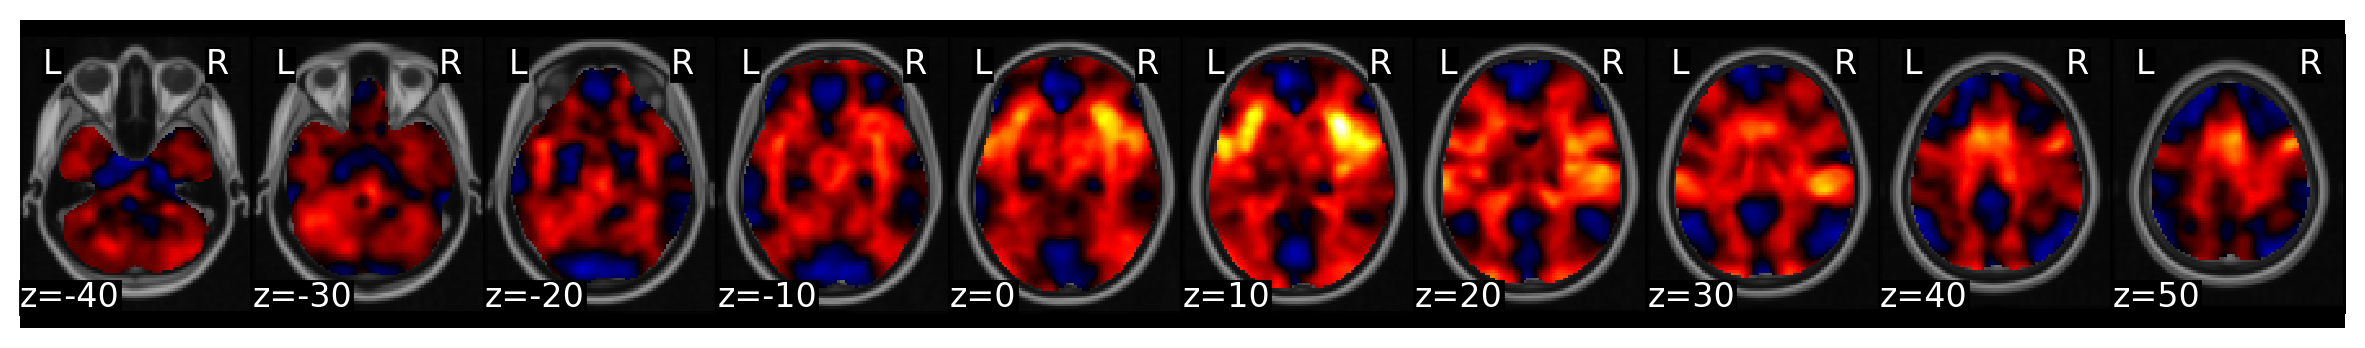

In [8]:
tsnr_brain = mean_brain / std_brain
tsnr_brain.plot()

If we instead use `axis = 1` we can easily create a plot of the global time-series across images:

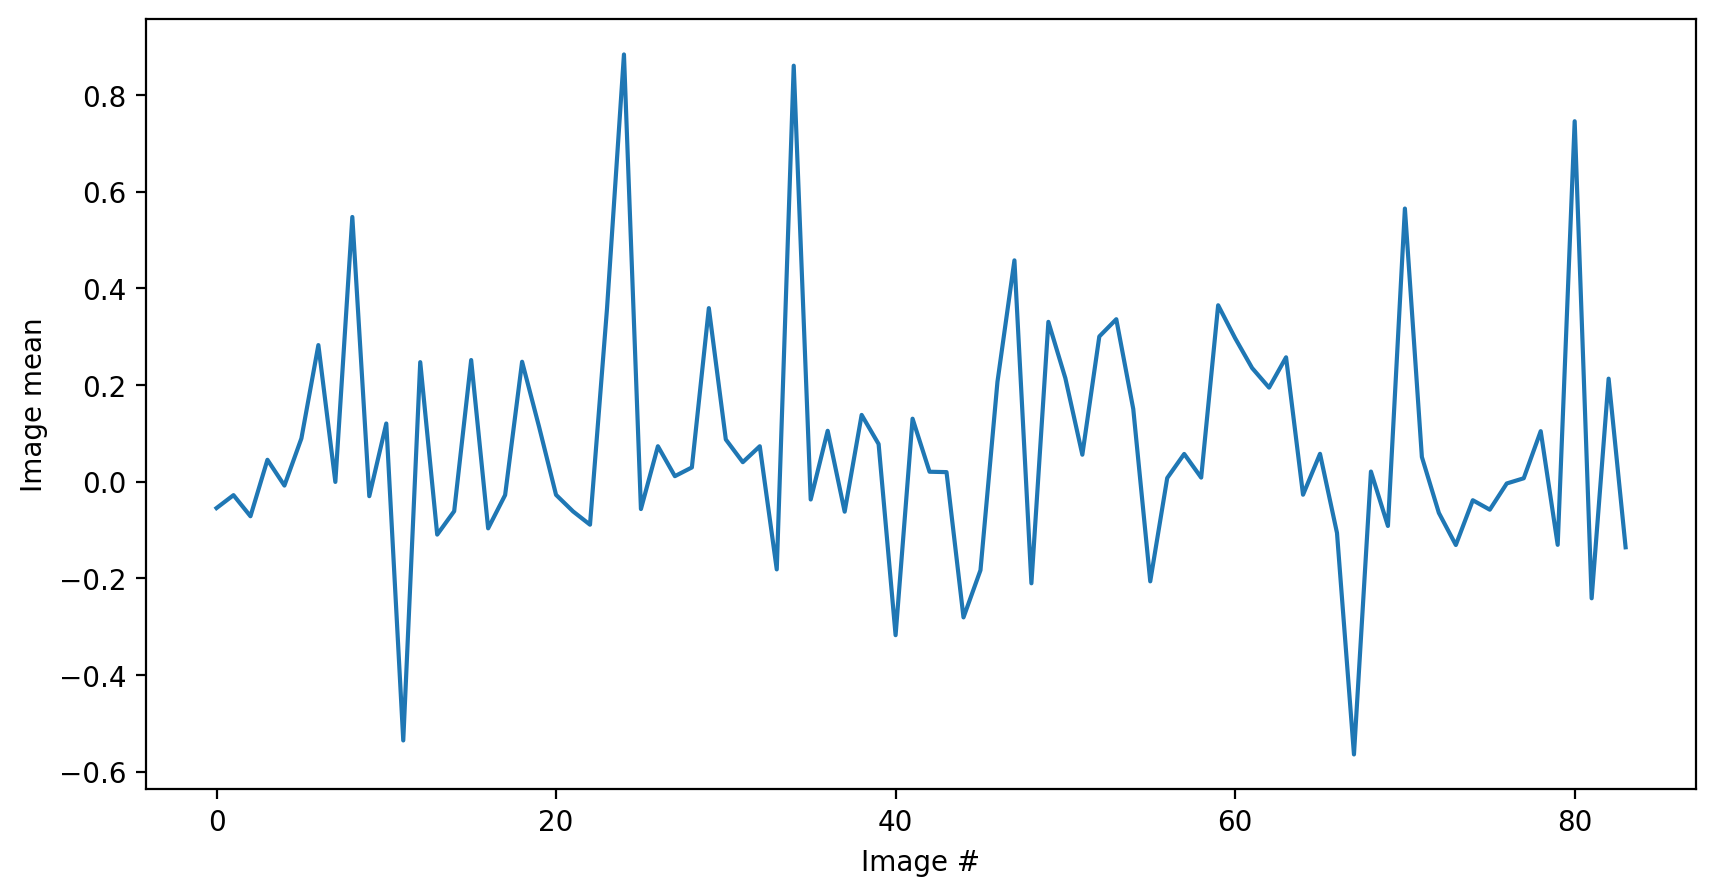

In [11]:
mean_timeseries = data.mean(axis=1)
f, ax = plt.subplots(figsize=(10, 5))
ax.plot(mean_timeseries)
ax.set_xlabel("Image #")
ax.set_ylabel("Image mean");

## Arithmetic Operations

Brain_Data supports element-wise arithmetic operations with scalars, arrays, or other Brain_Data objects.

In [11]:
data.mean().shape()

(238955,)

In [2]:
# Operations with scalars
scaled = data * 2  # multiply all voxels by 2
shifted = data + 100  # add 100 to all voxels

# Mean-center the data
centered = data - data.mean()
print(f"Mean of centered data: {centered.mean().mean():.10f}")  # Should be ~0

Mean of centered data: -0.0000000000


In [3]:
# Operations between Brain_Data objects
difference = data[1] - data[0]  # difference between first two images
difference

nltools.data.brain_data.Brain_Data(data=(238955,), Y=(0, 0), X=(63,), mask=MNI152_T1_2mm_brain_mask.nii.gz)

## Data Processing Methods

`Brain_Data` includes several built-in methods for common neuroimaging preprocessing and analysis steps.

In [4]:
# Standardize data (z-score)
z_scored = data.standardize()
print(f"Mean before z-scoring: {data.mean().data.mean():.10f}")
print(f"Mean after z-scoring: {z_scored.mean().data.mean():.10f}")

Mean before z-scoring: 0.0729805008
Mean after z-scoring: 0.0000000000


/Users/esh/Documents/pypackages/nltools/.venv/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(


In [5]:
# Spatial smoothing
smoothed = data[0].smooth(fwhm=6)  # 6mm FWHM Gaussian kernel
print(f"Original data range: [{data[0].data.min():.2f}, {data[0].data.max():.2f}]")
print(f"Smoothed data range: [{smoothed.data.min():.2f}, {smoothed.data.max():.2f}]")

Original data range: [-1.20, 0.75]
Smoothed data range: [-0.90, 0.36]


Methods can also be chained together:

In [6]:
# Thresholding
thresholded = data.mean().threshold(lower=2, upper=10)
print(f"Number of voxels above threshold: {(thresholded.data > 0).sum()}")

Number of voxels above threshold: 190390


## Visualization

Brain_Data provides several built-in visualization methods for exploring your data.

```{note}
`nltools` visualizations are relatively basic to aid in quick, interactive analyses.  
For more comprehensive visualizations we recommend using [`nilearn.plotting`](https://nilearn.github.io/stable/plotting/index.html) directly and passing in `data.to_nifti()` as the image to visualize for any of the plotting functions (it's what we do under-the-hood!)
```


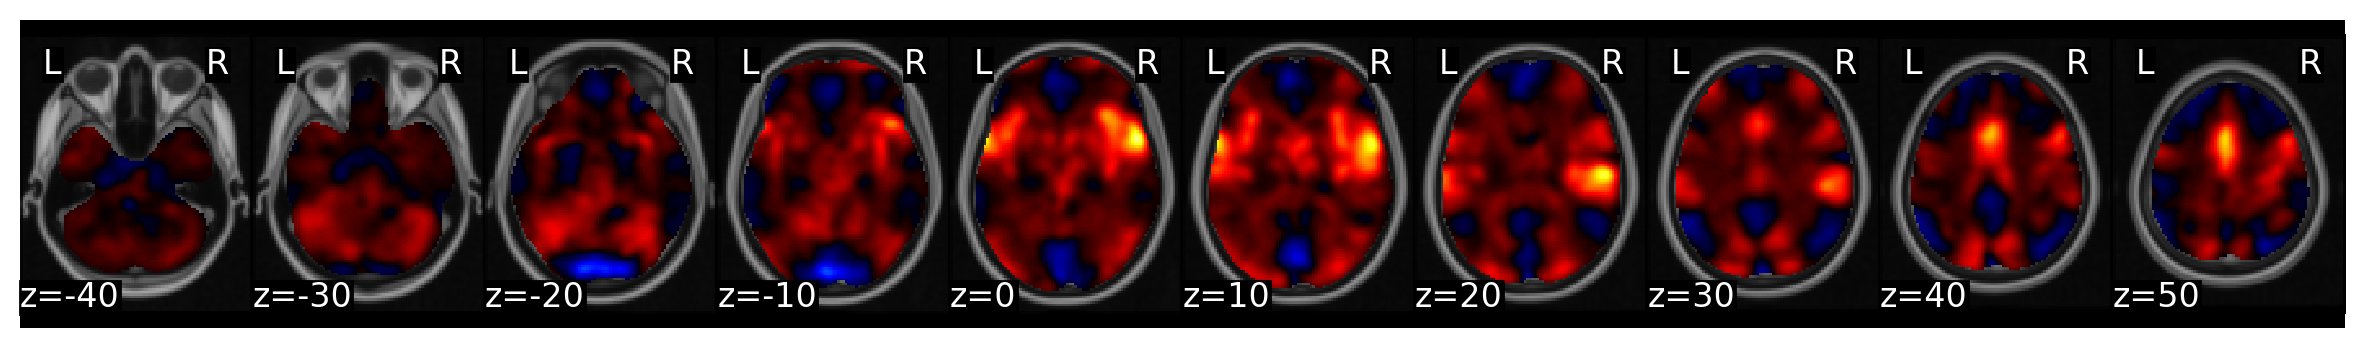

In [8]:
# Plot a statistical map
data.mean().plot()

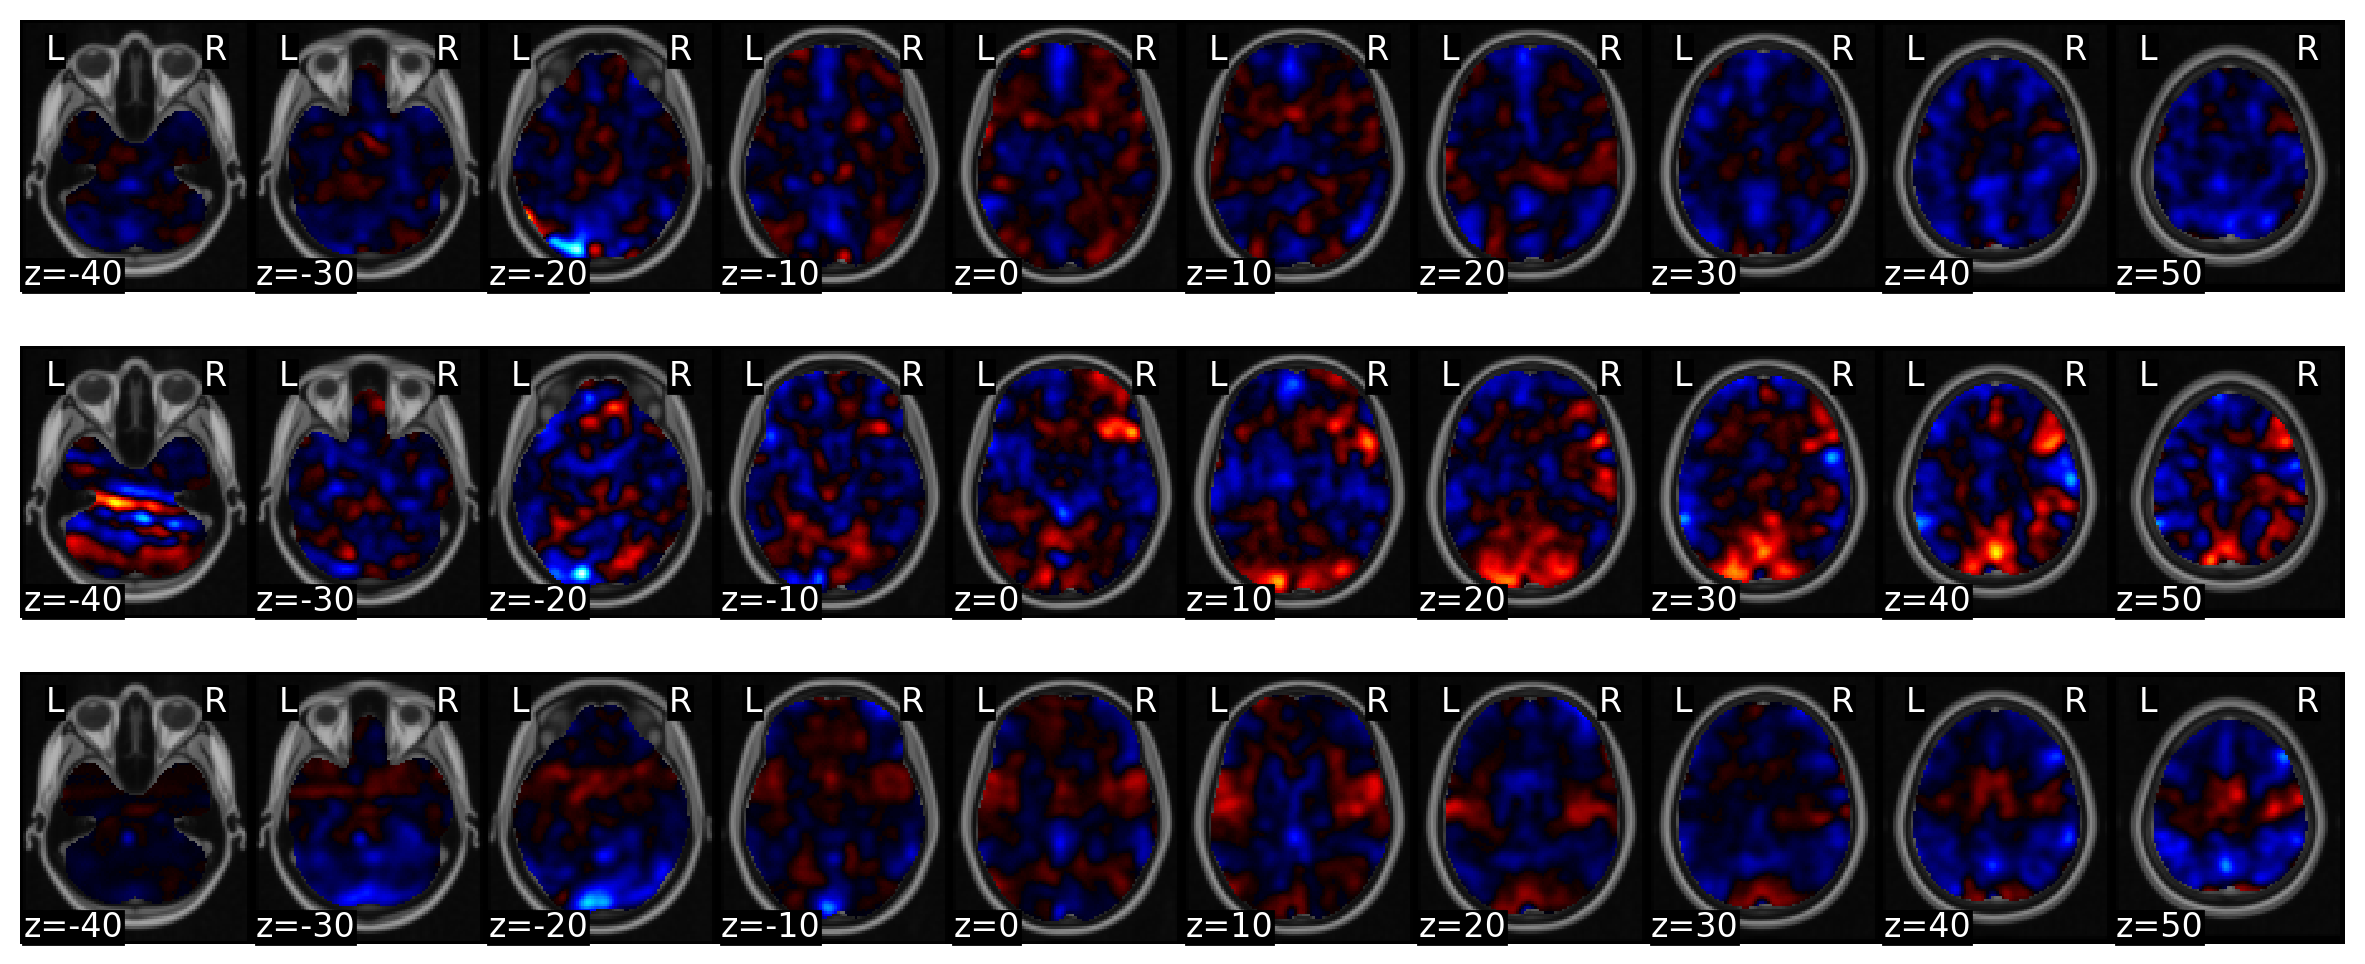

In [9]:
# Plot multiple images in a grid
data[:3].plot()

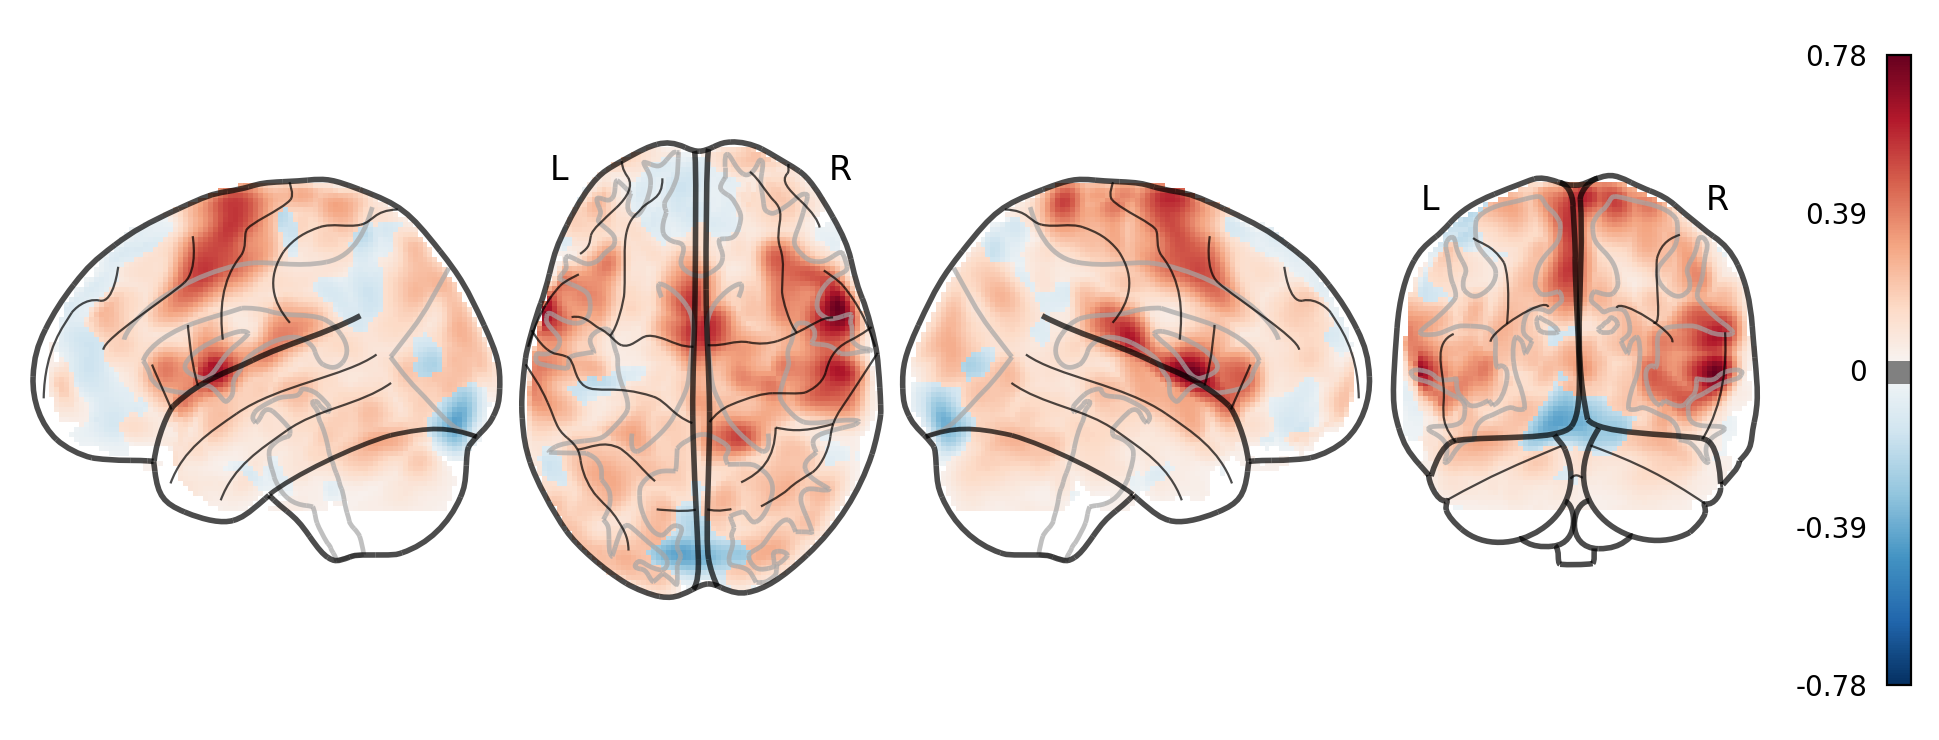

In [ ]:
# We can also plot a glass brain for a different view
data.mean().plot(view="glass")

In [ ]:
# Interactive plotting (requires additional dependencies)
data.mean().iplot()

## Working with Masks

Brain_Data objects can be masked to focus analyses on specific brain regions.

In [49]:
# Create a simple threshold-based mask filtering most negative values
mean_brain = data.mean()
mask = mean_brain.threshold(lower=-1e-10, binarize=True)
print(f"Number of voxels in mask: {mask.data.sum():.0f}")

Number of voxels in mask: 43457


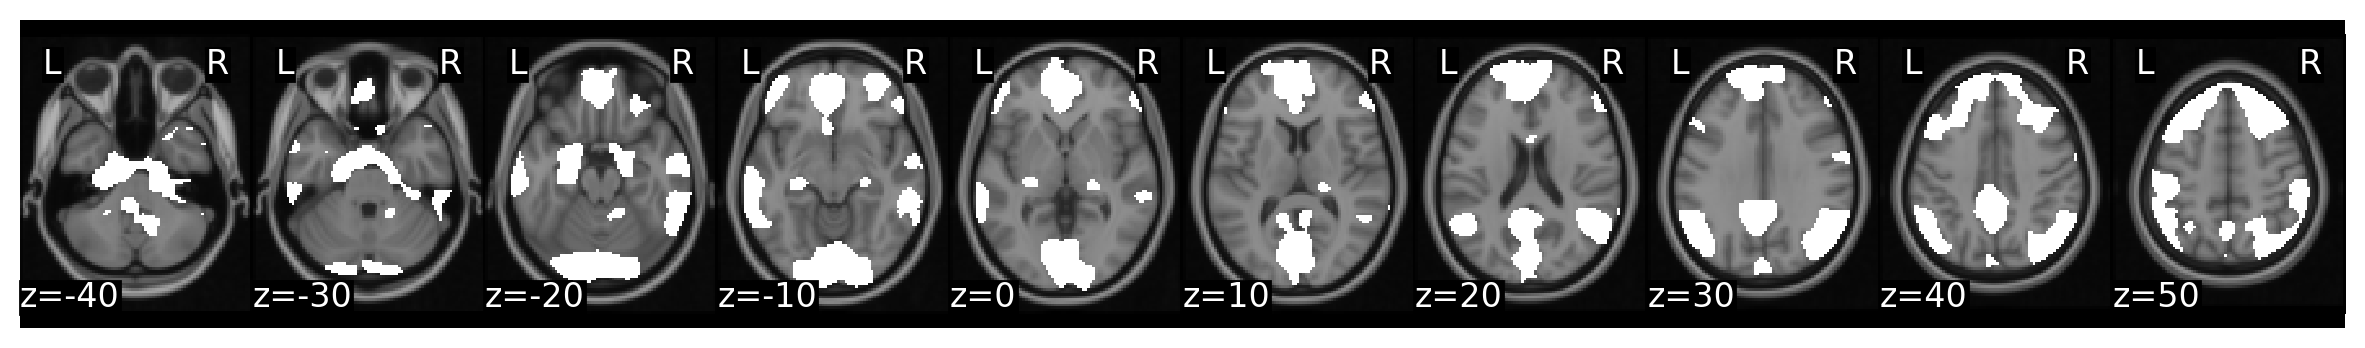

In [ ]:
# The binarized mask
mask.plot()

In [53]:
# Apply mask to data
masked_data = mean_brain.apply_mask(mask)

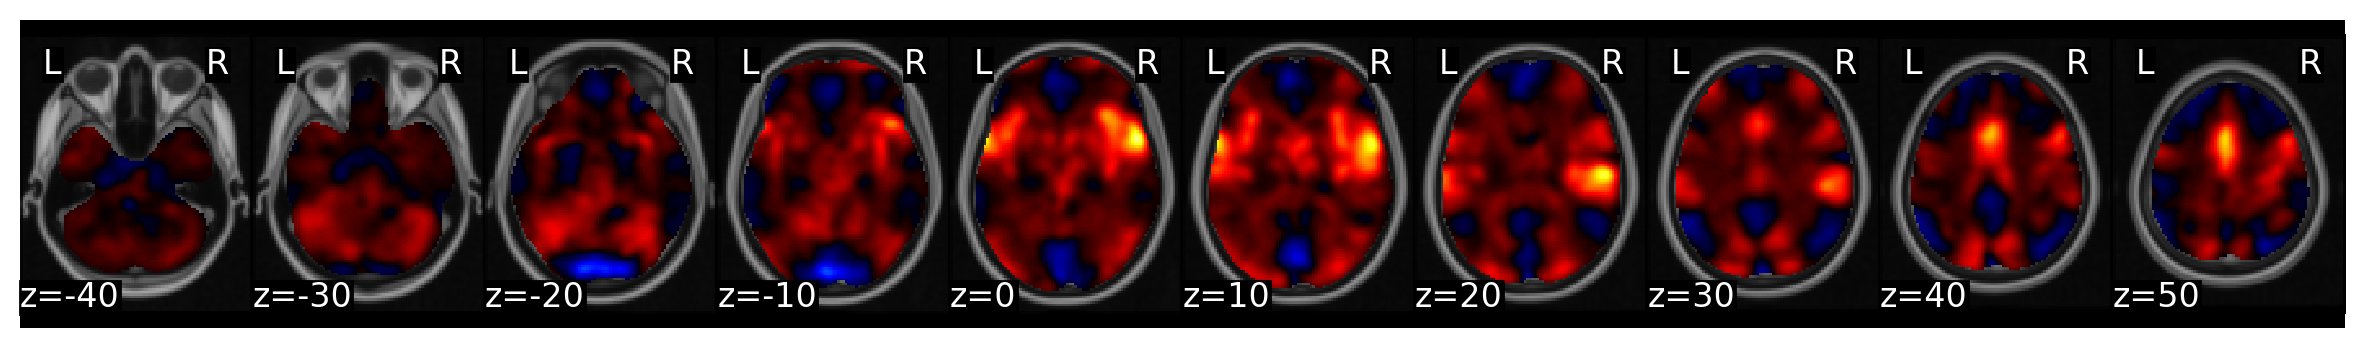

In [ ]:
# The original data
mean_brain.plot()

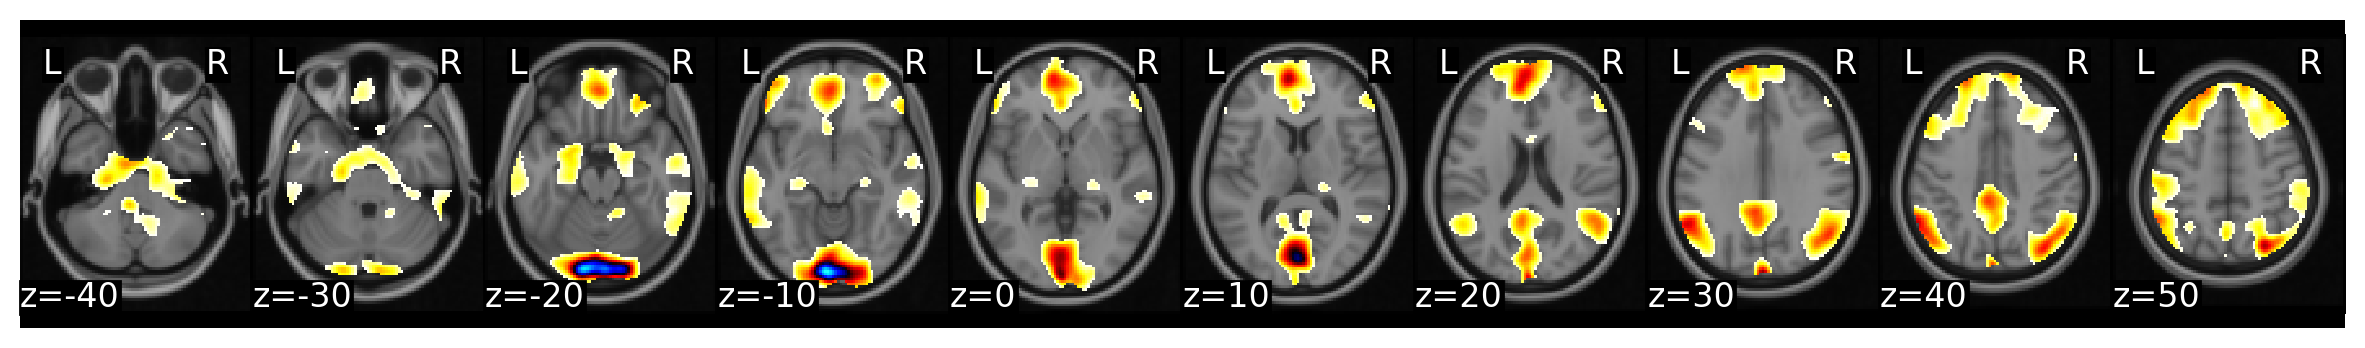

In [54]:
# The masked data
masked_data.plot()

## File I/O

Brain_Data makes it easy to save and load neuroimaging data in various formats.

In [ ]:
# Save as NIfTI file
mean_brain.write("mean_activation.nii.gz")

# Save as HDF5 (preserves metadata)
data.write("brain_data_with_metadata.h5")

In [ ]:
# Load from file
loaded_data = Brain_Data("mean_activation.nii.gz")

# Load from HDF5
loaded_h5 = Brain_Data("brain_data_with_metadata.h5")

## Converting Between Formats

Brain_Data provides seamless conversion to and from other neuroimaging data formats.


### Nifti

This makes it easy to work with other libraries like `nilearn` and `nibabel` that work with NIFTI images

In [56]:
# Convert to nibabel NIfTI object
nifti = mean_brain.to_nifti()

print(f"Type: {type(nifti)}")
print(f"NIfTI shape: {nifti.shape}")
print(f"NIfTI affine:\n{nifti.affine}")

Type: <class 'nibabel.nifti1.Nifti1Image'>
NIfTI shape: (91, 109, 91)
NIfTI affine:
[[  -2.    0.    0.   90.]
 [   0.    2.    0. -126.]
 [   0.    0.    2.  -72.]
 [   0.    0.    0.    1.]]


In [57]:
# Create Brain_Data from nibabel object
from_nifti = Brain_Data(nifti)
from_nifti

nltools.data.brain_data.Brain_Data(data=(238955,), Y=(0, 0), X=(0, 0), mask=MNI152_T1_2mm_brain_mask.nii.gz)

### Numpy

The `.data` attribute always stores data as a 2d numpy array, allowing you to manipulate it any way you like.

In [61]:
# Access the raw data array
raw_data = data.data

print(f"Type: {type(raw_data)}")
print(f"Raw data shape: {raw_data.shape}")
print(f"Data type: {raw_data.dtype}")

Type: <class 'numpy.ndarray'>
Raw data shape: (84, 238955)
Data type: float32


## Metadata and Design Information

Brain_Data objects can store experimental design information in the X and Y attributes as pandas dataframes.

These are useful for running GLM and prediction analyses as demonstrated in future tutorials.

In [59]:
# Check if design matrix X exists
if not data.X.empty:
    print(f"Design matrix shape: {data.X.shape}")
    print(f"Design matrix columns: {list(data.X.columns)[:10]}...")  # First 10 columns

Design matrix shape: (84, 63)
Design matrix columns: ['url', 'id', 'file', 'collection', 'collection_id', 'file_size', 'cognitive_paradigm_cogatlas', 'cognitive_paradigm_cogatlas_id', 'cognitive_contrast_cogatlas', 'cognitive_contrast_cogatlas_id']...


In [60]:
# Create labels for our data
labels = pd.DataFrame(
    {"condition": ["pain"] * 42 + ["no_pain"] * 42, "intensity": np.random.randn(84)}
)

# Create a new Brain_Data object with labels
labeled_data = Brain_Data(data.to_nifti(), Y=labels)
print(f"Labels shape: {labeled_data.Y.shape}")
labeled_data.Y.head()

Labels shape: (84, 2)


,condition,intensity
0,pain,0.499938
1,pain,1.224968
2,pain,-0.325179
3,pain,-0.257368
4,pain,-0.375559


## Summary

The Brain_Data class provides a powerful and intuitive interface for working with neuroimaging data:

- **Efficient storage**: Data is stored as 2D arrays (images × voxels) for fast computation
- **Flexible indexing**: Standard Python indexing and slicing operations
- **Built-in statistics**: Mean, standard deviation, and other statistics across images or voxels  
- **Arithmetic operations**: Element-wise operations with scalars or other Brain_Data objects
- **Processing methods**: Standardization, smoothing, thresholding, and masking
- **Visualization**: Multiple plotting options for data exploration
- **File I/O**: Save and load data in NIfTI or HDF5 formats
- **Metadata support**: Store experimental design information alongside brain data

In the next tutorial, we'll explore the DesignMatrix class for working with experimental designs and GLM analyses.